# Convert CIFAR10 data to pngs

To show overhead of loading individual files. This is intended to be used (and should be run before) the `PyTorch_profiling.ipynb` notebook.

In [1]:
import os
import pickle
import glob

import numpy as np
from PIL import Image
from torchvision import datasets

import matplotlib.pyplot as plt
%matplotlib inline

Create path to where pngs should be stored

In [2]:
DATA_PATH = os.getenv('TEACHER_DIR', os.getcwd()) + '/JHS_data'

png_path=os.path.join(DATA_PATH,'cifar10_png')
if not os.path.exists(png_path):
    os.makedirs(png_path)

print(f"Path to store cifar10 data: {DATA_PATH}")
print(f"Path to store pngs: {png_path}")

Path to store cifar10 data: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data
Path to store pngs: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png


Make sure Cifar10 data is present in the DATA_PATH

In [3]:
datasets.CIFAR10(DATA_PATH, train=False,  download=True),

  0%|          | 0.00/170M [00:00<?, ?B/s]

100%|██████████| 170M/170M [00:06<00:00, 26.7MB/s] 


(Dataset CIFAR10
     Number of datapoints: 10000
     Root location: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data
     Split: Test,)

Unpickle all cifar10 batches.

In [4]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

batch_dict1 = unpickle(os.path.join(DATA_PATH,'cifar-10-batches-py/data_batch_1'))
batch_dict2 = unpickle(os.path.join(DATA_PATH,'cifar-10-batches-py/data_batch_2'))
batch_dict3 = unpickle(os.path.join(DATA_PATH,'cifar-10-batches-py/data_batch_3'))
batch_dict4 = unpickle(os.path.join(DATA_PATH,'cifar-10-batches-py/data_batch_4'))
batch_dict5 = unpickle(os.path.join(DATA_PATH,'cifar-10-batches-py/data_batch_5'))

Check the content of these unpickled dictionaries

In [5]:
print(f"Number of items in one batch_dict: {len(batch_dict1[b'data'])}")
print(f"Keys: {batch_dict1.keys()}")
print(f"Dimension of raw image: {batch_dict1[b'data'][0].shape}")

Number of items in one batch_dict: 10000
Keys: dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
Dimension of raw image: (3072,)


We need to reshape the image, as it is now a flat array:

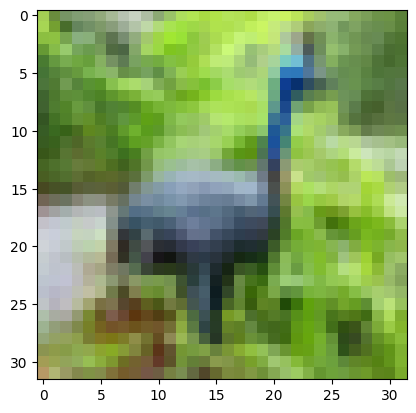

In [6]:
def convert_image(img):
    img = np.reshape(img,(3,32,32))
    img = np.moveaxis(img,0,2)
    return img

plt.imshow(convert_image(batch_dict1[b'data'][6]))

Define function that will loop over all images in a batch_dict, convert the shame, and store it as a png

In [7]:
def reshape_and_save(batch_dict):
    for img, filename in zip(batch_dict[b'data'],batch_dict[b'filenames']):
        img = convert_image(img)
        im = Image.fromarray(img)
        filename=os.path.join(png_path, str(filename,'utf-8'))
        print(f"Saving file: {filename}")
        im.save(f'{filename}')

Run the `reshape_and_save` function on each batch dict

In [8]:
reshape_and_save(batch_dict1)
reshape_and_save(batch_dict2)
reshape_and_save(batch_dict3)
reshape_and_save(batch_dict4)
reshape_and_save(batch_dict5)

Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/leptodactylus_pentadactylus_s_000004.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/camion_s_000148.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/tipper_truck_s_001250.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/american_elk_s_001521.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/station_wagon_s_000293.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/coupe_s_001735.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/cassowary_s_001300.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/cow_pony_s_001168.png
Saving file: /gpfs/scratch1/shared/HPML-course-mater

Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/pipit_s_000226.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/toy_dog_s_000960.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/delivery_truck_s_001121.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/bufo_marinus_s_001506.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/studhorse_s_000010.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/woodland_caribou_s_001003.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/station_wagon_s_000260.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/cifar10_png/pilot_boat_s_000356.png
Saving file: /gpfs/scratch1/shared/HPML-course-materials/D

Now, we need to also store the labels, in a way that they can be indexed by the filename:

In [9]:
filenames=batch_dict1[b'filenames'] + batch_dict2[b'filenames'] + batch_dict3[b'filenames'] + batch_dict4[b'filenames'] + batch_dict5[b'filenames']
labels=batch_dict1[b'labels'] + batch_dict2[b'labels'] + batch_dict3[b'labels'] + batch_dict4[b'labels'] + batch_dict5[b'labels']
print(len(filenames))
print(len(labels))

new_dict = {}
for i in range(0,len(labels)):
    new_dict[str(filenames[i],'utf-8')] = int(labels[i])

label_filename = os.path.join(DATA_PATH, "labels.pkl")
print(f"Storing labels at: {label_filename}")
with open(label_filename, "wb") as f:
    pickle.dump(new_dict, f)


50000
50000
Storing labels at: /gpfs/scratch1/shared/HPML-course-materials/Day2/notebooks/JHS_data/labels.pkl


Check that we can read images from the pngs:

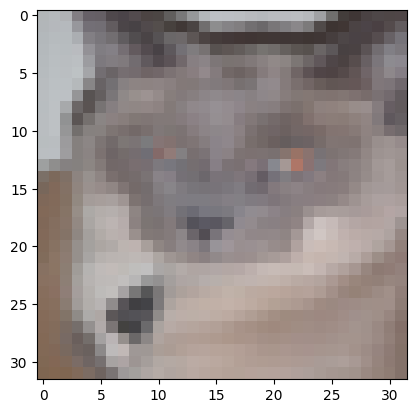

In [10]:
png_filenames = glob.glob(os.path.join(png_path, '*.png'))
img = Image.open(png_filenames[0])
plt.imshow(img)

Check that we can read the labels from the pkl. 0 = airplane, 1 = automobile, 2 = bird, 3 = cat, 4 = deer, 5 = dog, 6 = frog, 7 = horse, 8 = ship, 9 = truck

In [11]:
with open(label_filename, 'rb') as fo:
    label_dict = pickle.load(fo, encoding='bytes')

label_dict[os.path.basename(png_filenames[0])]

3

In [12]:
len(label_dict)

50000